# Tutorial 1: A First MI Estimate

Welcome to the `NeuralMI` tutorial series. This first tutorial has one goal:
get a reliable mutual information (MI) estimate out of the library as quickly as
possible, and understand what that number means.

**What is mutual information?** MI between two variables $X$ and $Y$ is defined as:

$$I(X; Y) = \mathbb{E}\left[\log \frac{p(x, y)}{p(x)\, p(y)}\right]$$

It measures how much knowing $X$ reduces your uncertainty about $Y$ (and vice versa).
It is measured in **bits** (when using log base 2). Unlike Pearson correlation,
MI captures *any* statistical dependence — linear or not.
$I(X; Y) = 0$ means $X$ and $Y$ are statistically independent.
There is no upper bound in general, but for Gaussian variables the MI is directly
related to the correlation structure and can be computed analytically —
which is what we will exploit here to verify our estimate.

**What kind of data does this tutorial use?**
We will use **Independent and Identically Distributed (IID)** data: each sample
is drawn independently from the same distribution, with no temporal ordering.
This is the simplest possible case and lets us focus on the estimation machinery
without worrying about temporal structure (that comes in Tutorial 2).

## 1. Imports

We import `neural_mi` as `nmi` — the standard convention used throughout all
tutorials — along with `numpy` and `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi

## 2. Generating the Data

We use `nmi.generators.generate_correlated_gaussians` to create two multivariate
Gaussian variables $X$ and $Y$ with a **known, exact MI in bits**.
This lets us verify that our estimate is correct.

The generator produces data of shape `(n_samples, n_dim)`.
Because we are not asking the library to do any windowing
(we pass `processor_type=None`, the default), the library expects
**pre-processed data** in the shape `(n_samples, n_channels)` — samples first.
Our generator output already matches this convention.

We set the ground truth MI to **2.0 bits** and use 5 dimensions for each variable.

In [ ]:
n_samples = 5000
dim = 5
ground_truth_mi = 2.0

x, y = nmi.generators.generate_correlated_gaussians(
    n_samples=n_samples, dim=dim, mi=ground_truth_mi
)

print(f"x shape: {x.shape}")  # Expected: (5000, 5)
print(f"y shape: {y.shape}")  # Expected: (5000, 5)

x shape: torch.Size([5000, 5])
y shape: torch.Size([5000, 5])


## 3. Visualising the Data

Before estimating anything, it is worth looking at the data.
The two variables are correlated Gaussians: $X$ and $Y$ share a latent
signal, but each is also corrupted by independent noise.
The scatter plots below show each dimension of $X$ against the corresponding
dimension of $Y$. The visible positive correlation is the signal MI is measuring.

Note that MI captures the *total* dependence across all five dimensions jointly,
not just pairwise correlations — the scatter plots give an intuition but are not
the full picture.

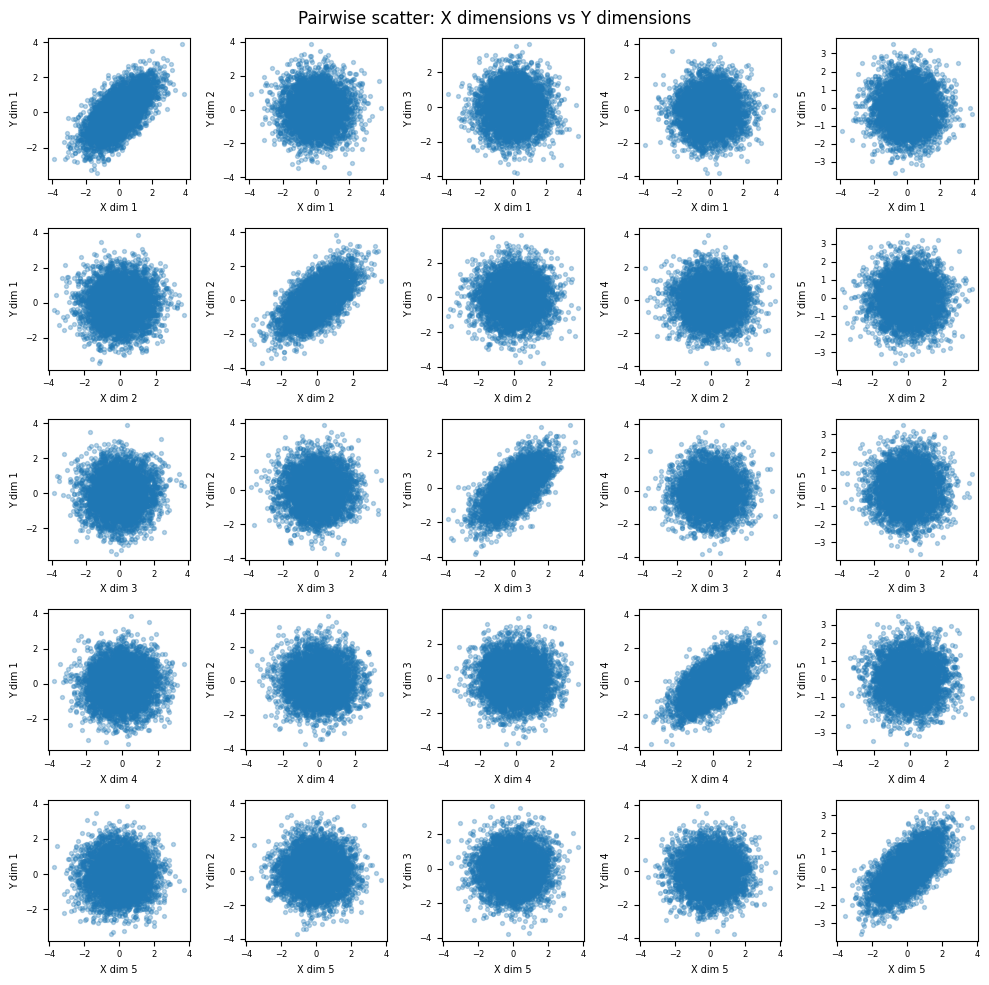

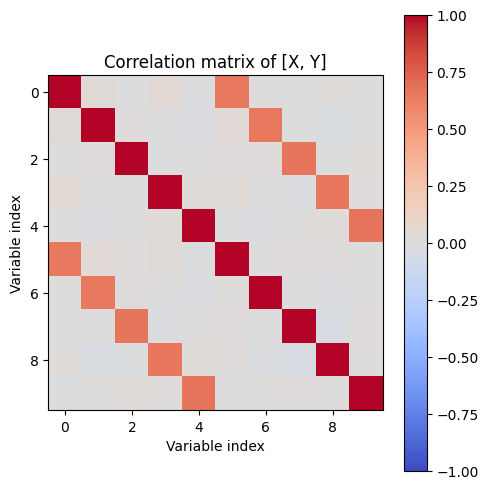

In [4]:
# --- Pairwise scatter plots: x[:, i] vs y[:, j] for all combinations ---
fig, axes = plt.subplots(dim, dim, figsize=(10, 10))
for i in range(dim):
    for j in range(dim):
        axes[i, j].scatter(x[:, i], y[:, j], alpha=0.3, s=8)
        axes[i, j].set_xlabel(f"X dim {i+1}", fontsize=7)
        axes[i, j].set_ylabel(f"Y dim {j+1}", fontsize=7)
        axes[i, j].tick_params(labelsize=6)
fig.suptitle("Pairwise scatter: X dimensions vs Y dimensions", fontsize=12)
plt.tight_layout()
plt.show()

# --- Full correlation matrix of the concatenated [X, Y] block ---
fig, ax = plt.subplots(figsize=(5, 5))
xy = np.hstack([x, y])  # shape: (n_samples, 2*dim)
corr = np.corrcoef(xy, rowvar=False)  # shape: (2*dim, 2*dim)
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix of [X, Y]")
ax.set_xlabel("Variable index")
ax.set_ylabel("Variable index")
plt.tight_layout()
plt.show()

## 4. Running the Estimation

The entire library is accessed through a single function: `nmi.run()`.
It accepts data, a mode, and configuration parameters, and returns a `Results` object.

For this tutorial we use `mode='estimate'` — the simplest mode, which trains
one MI estimator and returns a single number.

**The `split_mode` parameter** deserves special attention right away.
The estimator is a neural network trained on part of the data and evaluated
on a held-out test set. How we split the data matters:

- `split_mode='random'` — samples are shuffled before splitting. Use this
  **only when samples are truly independent** (IID data, like this tutorial).
- `split_mode='blocked'` — the test set consists of contiguous blocks drawn
  from across the recording, with a gap between train and test.
  Use this for **any time-series data** where adjacent samples are correlated.
  This is the default.

Our data here is IID, so `split_mode='random'` is correct.
We will revisit this choice carefully in **Tutorial 3**.

We pass `processor_type_x=None` and `processor_type_y=None` (the defaults)
because our data is already in the pre-processed `(n_samples, n_channels)` format.

In [5]:
results = nmi.run(
    x_data=x,
    y_data=y,
    mode='estimate',
    split_mode='random',
    # processor_type_x=None,  # default — pre-processed data, samples first
    # processor_type_y=None,
    # base_params={}           # using library defaults for architecture/training
)
# base_params controls the neural network architecture and training
# (epochs, learning rate, hidden dimensions). The defaults are reasonable
# for a first run; Tutorial 4 covers how to tune them.

Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Run d16cdf4f-ef5e-46f9-8566-9e65f8081708_c0:   0%|          | 0/50 [00:00<?, ?it/s]

## 5. Interpreting the Result

`nmi.run()` returns a `Results` object. For `mode='estimate'`, the key attribute
is `results.mi_estimate` — a single float, the estimated MI in bits.

Let's compare it to the ground truth we set when generating the data.

In [6]:
print("--- Results ---")
print(f"Ground truth MI : {ground_truth_mi:.3f} bits")
print(f"Estimated MI    : {results.mi_estimate:.3f} bits")
print(f"Absolute error  : {abs(results.mi_estimate - ground_truth_mi):.3f} bits")

--- Results ---
Ground truth MI : 2.000 bits
Estimated MI    : 1.921 bits
Absolute error  : 0.079 bits


## 6. The Effect of Sample Size

Our estimate should be close to 2.0 bits — but how close depends on how much
data we have. Neural MI estimators are **biased**: with finite data, they tend
to *overestimate* the true MI because the network can find spurious correlations
in noise. This bias shrinks as sample size grows.

Let's make this concrete by running the same estimation at several sample sizes.
This is a preview of a problem that **Tutorial 5** will solve rigorously.

 Sample size   Estimated MI (bits)   Error (bits)
--------------------------------------------------


Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Run 84d8b812-4ea8-4aa6-9fef-abebde27a008_c0:   0%|          | 0/50 [00:00<?, ?it/s]

         100                 1.495          0.505


Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

...

Run 4139f303-fe61-472c-9c62-bc5c4fed85a9_c0:   0%|          | 0/50 [00:00<?, ?it/s]

        3000                 1.824          0.176


Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Run a5f464e4-a030-43dc-8fb1-aec47b0dee6d_c0:   0%|          | 0/50 [00:00<?, ?it/s]

        5000                 1.928          0.072


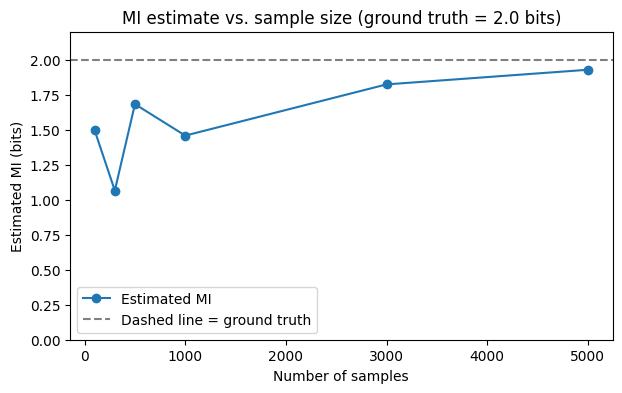

In [10]:
sample_sizes = [100, 300, 500, 1000, 3000, 5000]
estimates = []

print(f"{'Sample size':>12}  {'Estimated MI (bits)':>20}  {'Error (bits)':>13}")
print("-" * 50)

for n in sample_sizes:
    # Generate a fresh dataset at each sample size (same dimensionality and true MI)
    x_n, y_n = nmi.generators.generate_correlated_gaussians(
        n_samples=n, dim=dim, mi=ground_truth_mi
    )
    res_n = nmi.run(
        x_data=x_n,
        y_data=y_n,
        mode='estimate',
        split_mode='random',
    )
    est = res_n.mi_estimate
    estimates.append(est)
    print(f"{n:>12}  {est:>20.3f}  {abs(est - ground_truth_mi):>13.3f}")

# --- Plot: estimated MI vs sample size ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, estimates, 'o-', label="Estimated MI")
ax.axhline(ground_truth_mi, linestyle='--', color='gray', label="Dashed line = ground truth")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Estimated MI (bits)")
ax.set_title("MI estimate vs. sample size (ground truth = 2.0 bits)")
ax.legend()
plt.ylim(0, 2.2)
plt.show()

The pattern here is consistent with the theory: at small sample sizes (n = 200)
the estimate is noticeably above the ground truth of 2.0 bits — a positive bias.
As n increases, the estimate converges toward the ground truth, and at n = 5000
it should be within roughly 0.1 bits of 2.0.

This upward bias is not a bug — it is a fundamental property of finite-sample
MI estimation. Tutorial 5 introduces `mode='rigorous'`, which corrects for this
bias automatically and produces a confidence interval.

## 7. Key Takeaways

- **`nmi.run()` is the single entry point** for all analyses. It returns a
  `Results` object; `results.mi_estimate` is the estimated MI in bits.
- **Pre-processed IID data** should be passed as `(n_samples, n_channels)` with
  `processor_type=None` (the default). The shape convention changes when using
  raw time-series processors — see Tutorial 2.
- **`split_mode='random'`** is correct for IID data. For any recorded time series,
  use `split_mode='blocked'` (the default). Tutorial 3 explains why this matters.
- **MI estimates are biased upward at small sample sizes.** The bias decreases
  with more data. Tutorial 5 shows how to correct for it.
- The `base_params` dict controls the neural network. The defaults work for a
  first estimate; Tutorial 4 shows how to tune them systematically.

## Common Mistakes

1. **Wrong shape for pre-processed data.** If you pass `(n_channels, n_samples)`
   instead of `(n_samples, n_channels)`, the library will interpret channels as
   samples and samples as channels. Double-check your array orientation before calling
   `nmi.run()`. Use `x.shape` and confirm the first dimension matches your expected
   number of observations.

2. **Using `split_mode='random'` on time-series data.** If your samples come from
   a continuous recording (LFP, spike trains, kinematics), adjacent windows are
   correlated. A random split will leak correlated samples between train and test,
   inflating the MI estimate. Always use `split_mode='blocked'` for such data.
   See Tutorial 3 for a demonstration.

3. **Trusting a single estimate on small datasets.** The sample-size experiment
   above shows that estimates at n < 500 can be substantially biased. If your
   dataset is small, run `mode='rigorous'` (Tutorial 5) rather than taking
   a single `mode='estimate'` result at face value.

## What's Next

In **Tutorial 2**, we move from clean IID data to real neural recording formats:
continuous LFP-like time series, discrete spike trains, and categorical behavioral
states. We will see how the library windows and aligns these different data types,
and introduce the `processor_type` parameter that handles the raw-data path.